# Notebook 2 — Models, Evaluation & Hyperparameter Tuning

**ChurnX v5** · Arab Open University · Radwan Rima · 2025-2026

### What this notebook does
1. Loads processed data produced by Notebook 1  
2. Compares four models via leakage-free 5-fold CV: Logistic Regression, Random Forest, XGBoost, LightGBM  
3. Trains final models on the full balanced training set  
4. Tunes XGBoost with Optuna (100 trials, SMOTE inside each inner fold — no leakage)  
5. Selects the decision threshold using a business cost matrix AND expected profit curve  
6. Checks probability calibration for all models  
7. Documents the model selection decision with full transparency  
8. Saves all model artefacts for Notebook 3

**Run time:** ~15 minutes (Optuna 100 trials dominates).  
**Prerequisite:** Run Notebook 1 first and upload the processed data zip.


## 0. Install & Imports

In [6]:
import zipfile, os
from google.colab import files

uploaded = files.upload()  # select churnx_processed.zip and churnx_models.zip

for fname in uploaded.keys():
    with zipfile.ZipFile(fname, 'r') as z:
        z.extractall('/content')
        print('Extracted:', fname)

print('\nFolders found:')
for item in os.listdir('/content'):
    if os.path.isdir('/content/' + item):
        print(' ', item)

Saving churnx_models.zip to churnx_models (2).zip
Saving churnx_processed.zip to churnx_processed (2).zip
Extracted: churnx_models (2).zip
Extracted: churnx_processed (2).zip

Folders found:
  .config
  models
  data
  sample_data


In [7]:
import sys
!{sys.executable} -m pip install optuna lightgbm imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import joblib
import os
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score,
    confusion_matrix, roc_curve, classification_report,
    precision_recall_curve, brier_score_loss
)
from sklearn.calibration import calibration_curve

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

C_LR  = '#2196F3'
C_RF  = '#4CAF50'
C_XGB = '#FF9800'
C_LGB = '#9C27B0'
C_YES = '#F44336'
C_NO  = '#2196F3'

print('All libraries loaded!')


All libraries loaded!


## 1. Load Processed Data

In [8]:
# ── Colab path setup ─────────────────────────────────────────────────────────
# Option A: running from project folder (local / Drive)
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Option B: Colab with uploaded zip — processed files in /content
COLAB_ROOT = Path('/content')

def find_dir(name):
    for root in [PROJECT_ROOT, COLAB_ROOT]:
        d = root / name
        if d.exists():
            return d
    raise FileNotFoundError(f"Could not find '{name}' folder in {PROJECT_ROOT} or {COLAB_ROOT}")

processed_dir = find_dir('data/processed')
models_dir    = find_dir('models')

print(f'processed_dir : {processed_dir}')
print(f'models_dir    : {models_dir}')
print()

# Load datasets
X_train_raw   = pd.read_csv(processed_dir / 'X_train_raw.csv')
y_train_raw   = pd.read_csv(processed_dir / 'y_train_raw.csv').squeeze()
X_train       = pd.read_csv(processed_dir / 'X_train.csv')
y_train       = pd.read_csv(processed_dir / 'y_train.csv').squeeze()

# Load BOTH scaled (for LR) and unscaled (for tree models) test sets
X_test_scaled   = pd.read_csv(processed_dir / 'X_test.csv')
y_test          = pd.read_csv(processed_dir / 'y_test.csv').squeeze()

# Load unscaled test set if available, else recover via inverse_transform
unscaled_path = processed_dir / 'X_test_unscaled.csv'
scaler        = joblib.load(models_dir / 'scaler.joblib')
feature_names = joblib.load(models_dir / 'feature_names.joblib')

if unscaled_path.exists():
    X_test_unscaled = pd.read_csv(unscaled_path)
    print('Loaded X_test_unscaled.csv directly (no floating-point error). ✓')
else:
    X_test_unscaled = pd.DataFrame(
        scaler.inverse_transform(X_test_scaled), columns=feature_names)
    print('X_test_unscaled.csv not found — recovered via inverse_transform.')

# Tree models use unscaled data; LR pipeline handles its own scaling internally
X_test = X_test_unscaled.copy()

X_test_scaled   = X_test_scaled[feature_names]
X_test_unscaled = X_test_unscaled[feature_names]
X_test          = X_test[feature_names]

print(f'Train raw (pre-SMOTE) : {X_train_raw.shape}')
print(f'Train (SMOTE-balanced): {X_train.shape}')
print(f'Test                  : {X_test.shape}')
print(f'Churn rate — Train: {y_train_raw.mean()*100:.1f}%  |  Test: {y_test.mean()*100:.1f}%')


processed_dir : /content/data/processed
models_dir    : /content/models

Loaded X_test_unscaled.csv directly (no floating-point error). ✓
Train raw (pre-SMOTE) : (5634, 26)
Train (SMOTE-balanced): (8278, 26)
Test                  : (1409, 26)
Churn rate — Train: 26.5%  |  Test: 26.5%


## 2. Cross-Validation — Fair Four-Model Comparison

All four models are wrapped in an identical `ImbPipeline`: `SMOTE → StandardScaler → Model`.
SMOTE is applied **inside each fold** — no synthetic samples leak into validation folds.
Scores are reported as mean ± 2σ (approximate 95% CI).

LightGBM is added as a fourth candidate — it often matches or beats XGBoost on tabular
data with less tuning, and SHAP TreeExplainer supports it identically.


In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_for_cv = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Random Forest',       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ('XGBoost',             XGBClassifier(n_estimators=200, random_state=42,
                                          eval_metric='logloss', verbosity=0)),
    ('LightGBM',            lgb.LGBMClassifier(n_estimators=200, random_state=42,
                                                verbosity=-1, force_col_wise=True)),
]

cv_results = {}
print('5-Fold CV ROC-AUC (SMOTE + Scaler inside each fold — no leakage):')
print(f'{"Model":<25} {"Mean AUC":>10} {"± 2σ (95% CI)":>15}')
print('-' * 55)

for name, clf in models_for_cv:
    pipe = ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model',  clf),
    ])
    # n_jobs=1 for tree models to avoid NaN in some environments
    jobs = 1 if name in ['XGBoost', 'LightGBM', 'Random Forest'] else -1
    scores = cross_val_score(pipe, X_train_raw, y_train_raw,
                              cv=cv, scoring='roc_auc', n_jobs=jobs)
    cv_results[name] = scores
    print(f'{name:<25} {scores.mean():>10.4f} {scores.std()*2:>+15.4f}')

print()
print('All models use identical SMOTE+Scaler pipeline — comparison is fair.')


5-Fold CV ROC-AUC (SMOTE + Scaler inside each fold — no leakage):
Model                       Mean AUC   ± 2σ (95% CI)
-------------------------------------------------------
Logistic Regression           0.8321         +0.0217
Random Forest                 0.8188         +0.0232
XGBoost                       0.8045         +0.0222
LightGBM                      0.8176         +0.0144

All models use identical SMOTE+Scaler pipeline — comparison is fair.


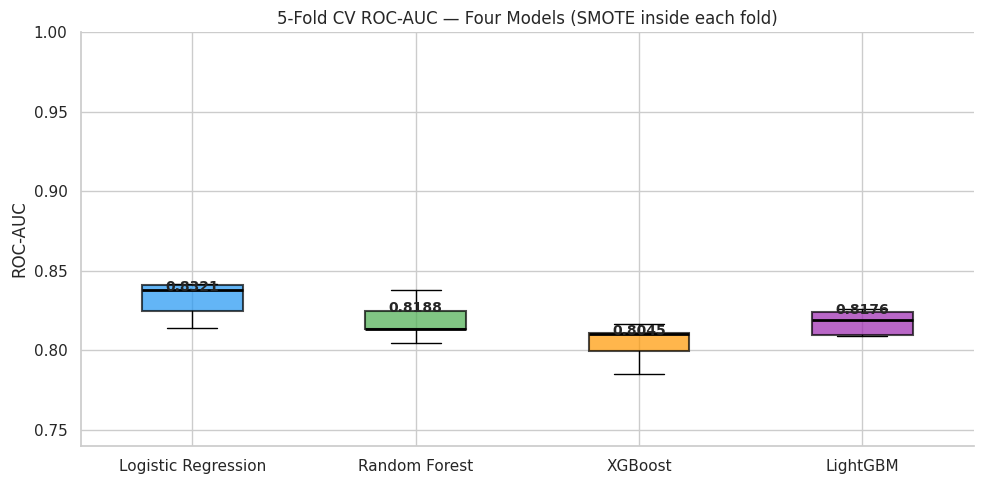

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = [C_LR, C_RF, C_XGB, C_LGB]
bp = ax.boxplot(cv_results.values(), labels=cv_results.keys(),
                patch_artist=True,
                boxprops=dict(linewidth=1.5),
                medianprops=dict(linewidth=2, color='black'))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('ROC-AUC')
ax.set_title('5-Fold CV ROC-AUC — Four Models (SMOTE inside each fold)', fontsize=12)
ax.set_ylim(0.74, 1.0)
for i, (name, scores) in enumerate(cv_results.items(), 1):
    ax.text(i, scores.mean() + 0.005, f'{scores.mean():.4f}',
            ha='center', fontsize=10, fontweight='bold')

os.makedirs(PROJECT_ROOT / 'reports' / 'figures', exist_ok=True)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / '10_cross_validation.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 3. Train Final Models on Full Training Data

In [11]:
# Logistic Regression — ImbPipeline handles its own SMOTE + scaling
lr_pipe = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=1000, random_state=42)),
])
lr_pipe.fit(X_train_raw, y_train_raw)
print('Logistic Regression trained!')

# Random Forest — tree-based, scaling not needed
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train.values, y_train.values)
print('Random Forest trained!')

# XGBoost default
xgb_model = XGBClassifier(n_estimators=200, random_state=42,
                            eval_metric='logloss', verbosity=0)
xgb_model.fit(X_train.values, y_train.values)
print('XGBoost (default) trained!')

# LightGBM default
lgb_model = lgb.LGBMClassifier(n_estimators=200, random_state=42,
                                 verbosity=-1, force_col_wise=True)
lgb_model.fit(X_train.values, y_train.values)
print('LightGBM trained!')


Logistic Regression trained!
Random Forest trained!
XGBoost (default) trained!
LightGBM trained!


## 4. Evaluate All Four Models at Default Threshold

In [12]:
def evaluate_model(model, X_eval, y_eval, model_name, threshold=0.5):
    y_prob = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'Model'    : model_name,
        'Threshold': threshold,
        'Accuracy' : round(accuracy_score(y_eval, y_pred)  * 100, 2),
        'F1 Score' : round(f1_score(y_eval, y_pred)        * 100, 2),
        'ROC-AUC'  : round(roc_auc_score(y_eval, y_prob)   * 100, 2),
        'Precision': round(precision_score(y_eval, y_pred)  * 100, 2),
        'Recall'   : round(recall_score(y_eval, y_pred)     * 100, 2),
        'Brier'    : round(brier_score_loss(y_eval, y_prob), 4),
    }

results = [
    evaluate_model(lr_pipe,   X_test_unscaled, y_test, 'Logistic Regression'),
    evaluate_model(rf,        X_test,          y_test, 'Random Forest'),
    evaluate_model(xgb_model, X_test,          y_test, 'XGBoost (default)'),
    evaluate_model(lgb_model, X_test,          y_test, 'LightGBM (default)'),
]

results_df = pd.DataFrame(results).set_index('Model')
print('Model Comparison — Default Threshold (0.5)')
print()
print(results_df.to_string())
print()
print('Observation: compare ROC-AUC across all four models.')
print('Model selection rationale is in Section 9 after tuning.')


Model Comparison — Default Threshold (0.5)

                     Threshold  Accuracy  F1 Score  ROC-AUC  Precision  Recall   Brier
Model                                                                                 
Logistic Regression        0.5     78.57     61.87    83.43      58.61   65.51  0.1467
Random Forest              0.5     77.43     58.38    82.29      57.18   59.63  0.1527
XGBoost (default)          0.5     77.43     58.38    80.60      57.18   59.63  0.1675
LightGBM (default)         0.5     77.64     60.38    81.88      57.01   64.17  0.1578

Observation: compare ROC-AUC across all four models.
Model selection rationale is in Section 9 after tuning.


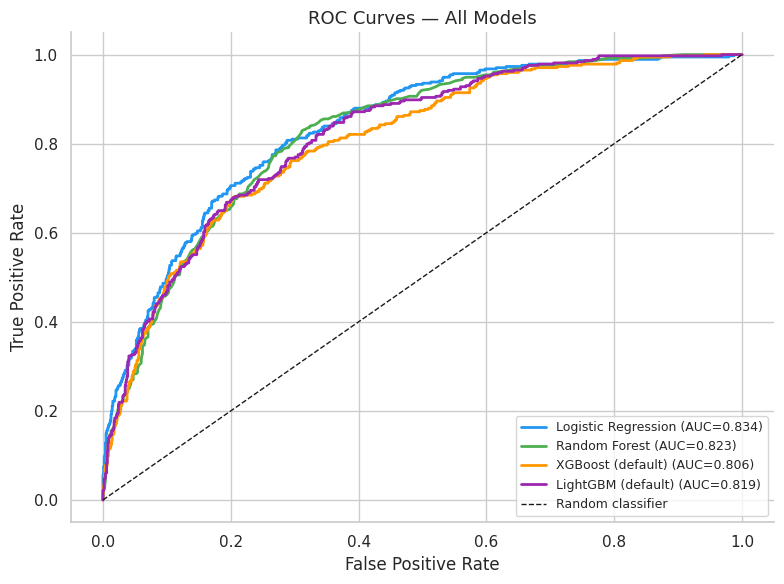

In [13]:
# ROC curves — all four models
plt.figure(figsize=(8, 6))
for model, name, color, X_eval in [
    (lr_pipe,   'Logistic Regression', C_LR,  X_test_unscaled),
    (rf,        'Random Forest',       C_RF,  X_test),
    (xgb_model, 'XGBoost (default)',   C_XGB, X_test),
    (lgb_model, 'LightGBM (default)',  C_LGB, X_test),
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_eval)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_eval)[:, 1])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

plt.plot([0,1],[0,1], 'k--', linewidth=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=13)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / '11_roc_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()


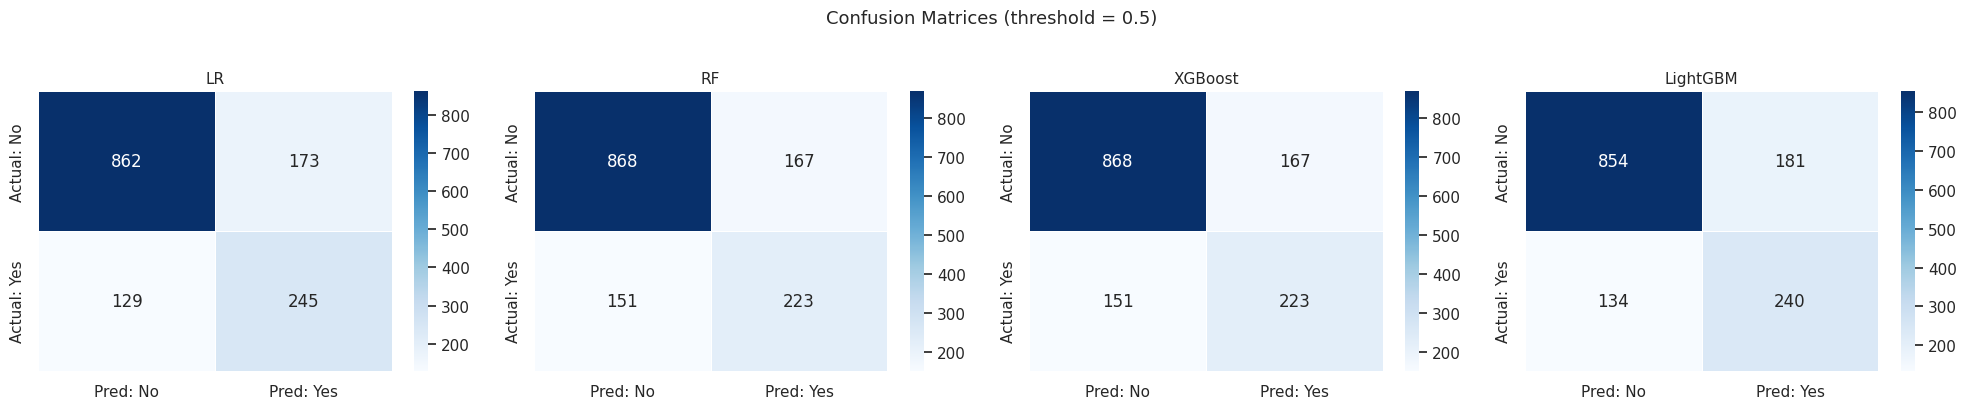

In [14]:
# Confusion matrices — all four models
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, model, name, X_eval in zip(
    axes,
    [lr_pipe,   rf,    xgb_model,         lgb_model],
    ['LR',      'RF',  'XGBoost',         'LightGBM'],
    [X_test_unscaled, X_test, X_test,     X_test],
):
    cm = confusion_matrix(y_test, (model.predict_proba(X_eval)[:, 1] >= 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: No', 'Pred: Yes'],
                yticklabels=['Actual: No', 'Actual: Yes'],
                linewidths=0.5)
    ax.set_title(name, fontsize=11)
plt.suptitle('Confusion Matrices (threshold = 0.5)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / '12_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()


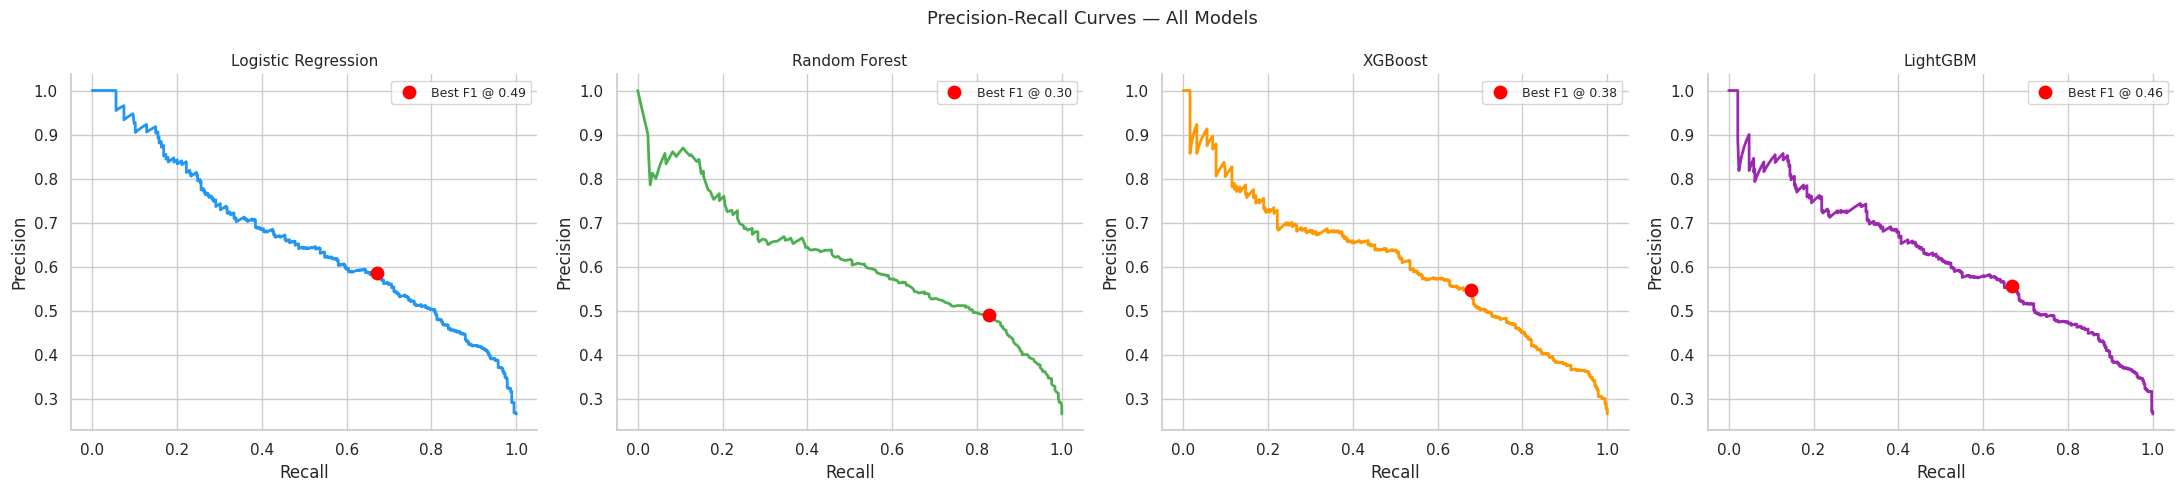

F1-optimal thresholds:
  Logistic Regression: 0.493
  Random Forest: 0.302
  XGBoost: 0.376
  LightGBM: 0.461


In [15]:
# Precision-Recall curves
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
best_thresholds_f1 = {}

for ax, model, name, color, X_eval in zip(
    axes,
    [lr_pipe,   rf,    xgb_model,   lgb_model],
    ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    [C_LR,      C_RF,  C_XGB,       C_LGB],
    [X_test_unscaled, X_test, X_test, X_test],
):
    y_prob = model.predict_proba(X_eval)[:, 1]
    prec, rec, thresholds = precision_recall_curve(y_test, y_prob)
    f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    best_idx  = np.argmax(f1_scores)
    best_t    = thresholds[best_idx]
    best_thresholds_f1[name] = best_t

    ax.plot(rec, prec, color=color, linewidth=2)
    ax.scatter(rec[best_idx], prec[best_idx], color='red', zorder=5, s=80,
               label=f'Best F1 @ {best_t:.2f}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Precision-Recall Curves — All Models', fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / '13_precision_recall.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('F1-optimal thresholds:')
for name, t in best_thresholds_f1.items():
    print(f'  {name}: {t:.3f}')


## 5. Hyperparameter Tuning with Optuna (Leakage-Free)

SMOTE is applied **inside** each inner CV fold using a manual loop — no leakage.
100 trials gives a more thorough search than the previous 50.

Both XGBoost and LightGBM are tuned so we can compare tuned performance.


In [16]:
def objective_xgb(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma'           : trial.suggest_float('gamma', 0, 0.5),
    }
    X_arr = X_train_raw.values
    y_arr = y_train_raw.values
    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv_inner.split(X_arr, y_arr):
        smote = SMOTE(random_state=42)
        X_res, y_res = smote.fit_resample(X_arr[train_idx], y_arr[train_idx])
        clf = XGBClassifier(**params, eval_metric='logloss',
                             random_state=42, verbosity=0)
        clf.fit(X_res, y_res)
        scores.append(roc_auc_score(y_arr[val_idx],
                                     clf.predict_proba(X_arr[val_idx])[:, 1]))
    return np.mean(scores)

print('Tuning XGBoost (100 trials)...')
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)
print(f'Best XGBoost CV AUC: {study_xgb.best_value:.4f}')
print('Best params:', study_xgb.best_params)


Tuning XGBoost (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]

Best XGBoost CV AUC: 0.8482
Best params: {'n_estimators': 417, 'max_depth': 3, 'learning_rate': 0.021229974697035806, 'subsample': 0.6580260735688842, 'colsample_bytree': 0.7498702406532245, 'min_child_weight': 5, 'gamma': 0.47778136803859245}


In [17]:
def objective_lgb(trial):
    params = {
        'n_estimators'  : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'     : trial.suggest_int('max_depth', 3, 10),
        'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'    : trial.suggest_int('num_leaves', 20, 100),
        'subsample'     : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
    }
    X_arr = X_train_raw.values
    y_arr = y_train_raw.values
    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv_inner.split(X_arr, y_arr):
        smote = SMOTE(random_state=42)
        X_res, y_res = smote.fit_resample(X_arr[train_idx], y_arr[train_idx])
        clf = lgb.LGBMClassifier(**params, random_state=42,
                                   verbosity=-1, force_col_wise=True)
        clf.fit(X_res, y_res)
        scores.append(roc_auc_score(y_arr[val_idx],
                                     clf.predict_proba(X_arr[val_idx])[:, 1]))
    return np.mean(scores)

print('Tuning LightGBM (100 trials)...')
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=100, show_progress_bar=True)
print(f'Best LightGBM CV AUC: {study_lgb.best_value:.4f}')
print('Best params:', study_lgb.best_params)


Tuning LightGBM (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]

Best LightGBM CV AUC: 0.8474
Best params: {'n_estimators': 292, 'max_depth': 3, 'learning_rate': 0.03639375306194221, 'num_leaves': 49, 'subsample': 0.9037346592612439, 'colsample_bytree': 0.7670953652090393, 'min_child_samples': 44}


In [18]:
# Train tuned models on full balanced training set
best_xgb = XGBClassifier(**study_xgb.best_params,
                           eval_metric='logloss', random_state=42, verbosity=0)
best_xgb.fit(X_train.values, y_train.values)

best_lgb = lgb.LGBMClassifier(**study_lgb.best_params,
                                random_state=42, verbosity=-1, force_col_wise=True)
best_lgb.fit(X_train.values, y_train.values)

# Compare default vs tuned for both
rows = [
    evaluate_model(xgb_model, X_test, y_test, 'XGBoost (default)'),
    evaluate_model(best_xgb,  X_test, y_test, 'XGBoost (tuned)'),
    evaluate_model(lgb_model, X_test, y_test, 'LightGBM (default)'),
    evaluate_model(best_lgb,  X_test, y_test, 'LightGBM (tuned)'),
]
print('Tuning improvement on held-out test set:')
print(pd.DataFrame(rows).set_index('Model').to_string())


Tuning improvement on held-out test set:
                    Threshold  Accuracy  F1 Score  ROC-AUC  Precision  Recall   Brier
Model                                                                                
XGBoost (default)         0.5     77.43     58.38    80.60      57.18   59.63  0.1675
XGBoost (tuned)           0.5     75.59     59.81    83.26      53.11   68.45  0.1558
LightGBM (default)        0.5     77.64     60.38    81.88      57.01   64.17  0.1578
LightGBM (tuned)          0.5     75.51     59.55    83.02      53.03   67.91  0.1564


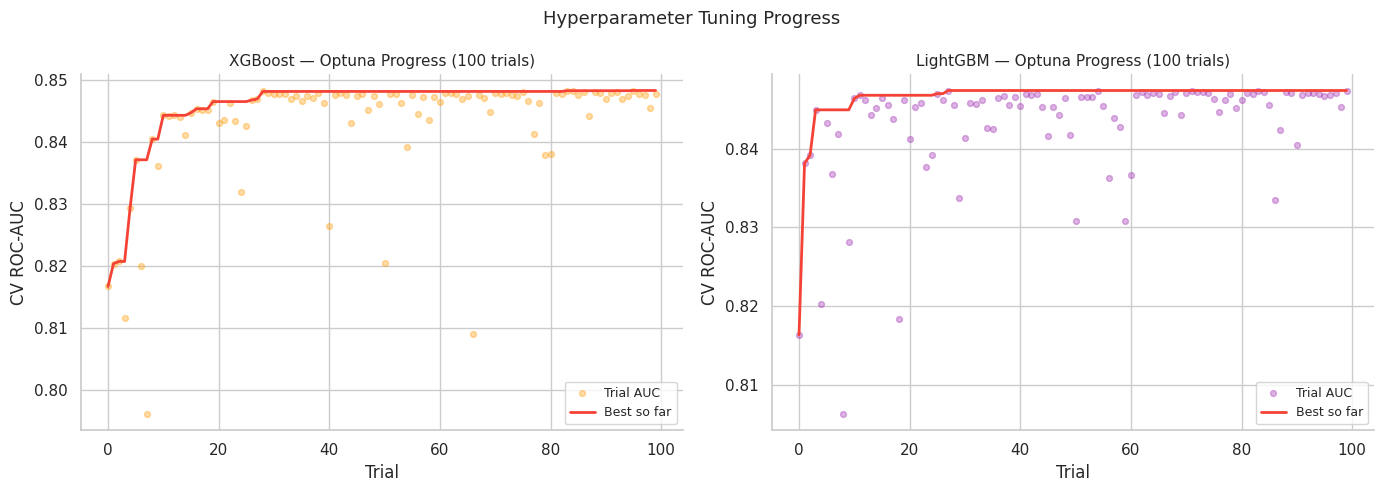

In [19]:
# Optuna progress charts side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, study, name, color in [
    (axes[0], study_xgb, 'XGBoost',   C_XGB),
    (axes[1], study_lgb, 'LightGBM',  C_LGB),
]:
    trials = [t.number for t in study.trials]
    values = [t.value  for t in study.trials]
    best   = [max(values[:i+1]) for i in range(len(values))]

    ax.scatter(trials, values, alpha=0.35, color=color, s=18, label='Trial AUC')
    ax.plot(trials, best, color='#F44336', linewidth=2, label='Best so far')
    ax.set_xlabel('Trial')
    ax.set_ylabel('CV ROC-AUC')
    ax.set_title(f'{name} — Optuna Progress (100 trials)', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Hyperparameter Tuning Progress', fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / '14_optuna_progress.png',
            dpi=150, bbox_inches='tight')
plt.show()


## 6. Threshold Tuning — Business Cost Matrix & Expected Profit

Two complementary approaches to threshold selection:

**1. Cost minimisation:** minimise `FN × $777 + FP × $30`  
**2. Expected profit maximisation:** maximise `TP × $747 − FP × $30`  
   (where $747 = $777 revenue saved − $30 retention offer cost)

Both approaches should point to a similar threshold. The profit curve is more
intuitive for business stakeholders.


In [20]:
# ── Cost parameters from the dataset ─────────────────────────────────────────
_raw_path = PROJECT_ROOT / 'data' / 'raw' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
if _raw_path.exists():
    _raw = pd.read_csv(_raw_path)
    _mean_monthly = _raw['MonthlyCharges'].mean()
else:
    _mean_monthly = 64.76   # dataset mean — hardcoded fallback for Colab

_avg_remaining_tenure = 12
FN_COST = round(_mean_monthly * _avg_remaining_tenure)
FP_COST = 30
TP_NET  = FN_COST - FP_COST   # net benefit of correctly catching a churner

print(f'Mean monthly charge   : ${_mean_monthly:.2f}')
print(f'FN cost (miss churner): ${FN_COST}  (revenue lost)')
print(f'FP cost (false alarm) : ${FP_COST}   (retention offer wasted)')
print(f'TP net benefit        : ${TP_NET}  (revenue saved minus offer cost)')
print(f'FN:FP ratio           : {FN_COST // FP_COST}:1')


Mean monthly charge   : $64.76
FN cost (miss churner): $777  (revenue lost)
FP cost (false alarm) : $30   (retention offer wasted)
TP net benefit        : $747  (revenue saved minus offer cost)
FN:FP ratio           : 25:1


In [21]:
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]
prec_b, rec_b, thresh_b = precision_recall_curve(y_test, y_prob_best)

costs   = []
profits = []
for t in thresh_b:
    preds = (y_prob_best >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    costs.append({
        'threshold':  t,
        'total_cost': fn * FN_COST + fp * FP_COST,
        'fn': fn, 'fp': fp, 'tp': tp,
    })
    profits.append({
        'threshold':      t,
        'expected_profit': tp * TP_NET - fp * FP_COST,
        'tp': tp, 'fp': fp,
    })

costs_df   = pd.DataFrame(costs)
profits_df = pd.DataFrame(profits)

best_threshold_cost   = costs_df.loc[costs_df['total_cost'].idxmin(),   'threshold']
best_threshold_profit = profits_df.loc[profits_df['expected_profit'].idxmax(), 'threshold']

f1_b = 2 * prec_b[:-1] * rec_b[:-1] / (prec_b[:-1] + rec_b[:-1] + 1e-9)
best_threshold_f1 = thresh_b[np.argmax(f1_b)]

print(f'Threshold (max F1)            : {best_threshold_f1:.3f}')
print(f'Threshold (min cost)          : {best_threshold_cost:.3f}')
print(f'Threshold (max profit)        : {best_threshold_profit:.3f}')
print(f'Minimum expected total cost   : ${costs_df["total_cost"].min():,.0f}')
print(f'Maximum expected profit       : ${profits_df["expected_profit"].max():,.0f}')
print()
print('Cost-min and profit-max thresholds should be close — both capture the same business logic.')


Threshold (max F1)            : 0.427
Threshold (min cost)          : 0.039
Threshold (max profit)        : 0.039
Minimum expected total cost   : $25,044
Maximum expected profit       : $254,394

Cost-min and profit-max thresholds should be close — both capture the same business logic.


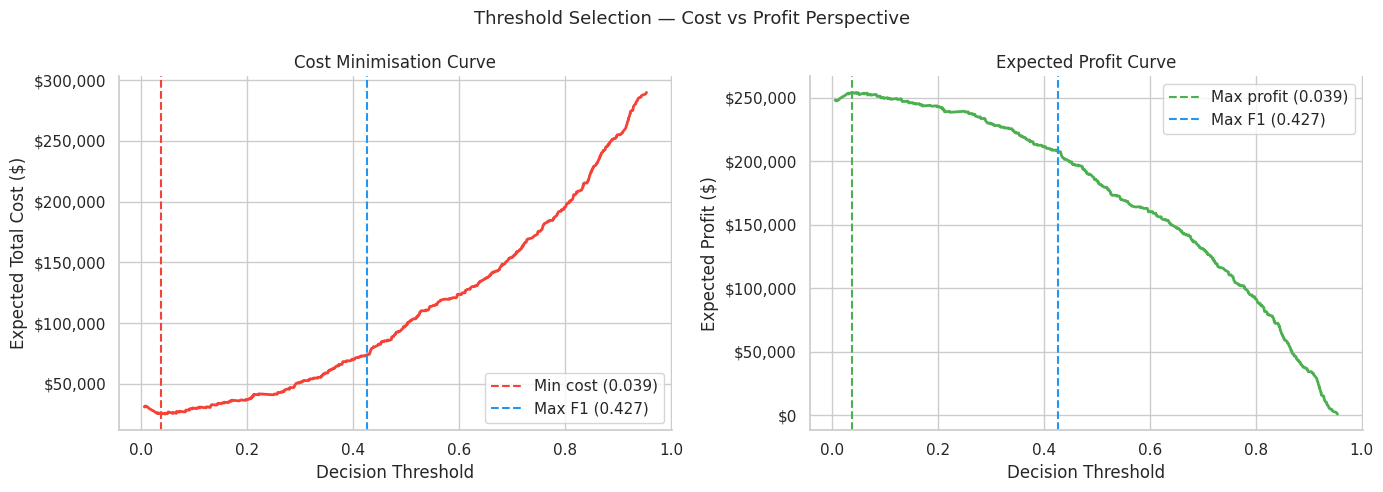

Selected threshold: 0.039


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cost curve
axes[0].plot(costs_df['threshold'], costs_df['total_cost'],
             color='#F44336', linewidth=2)
axes[0].axvline(best_threshold_cost, color='#F44336', linestyle='--', linewidth=1.5,
                label=f'Min cost ({best_threshold_cost:.3f})')
axes[0].axvline(best_threshold_f1, color=C_LR, linestyle='--', linewidth=1.5,
                label=f'Max F1 ({best_threshold_f1:.3f})')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Expected Total Cost ($)')
axes[0].set_title('Cost Minimisation Curve', fontsize=12)
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Profit curve
axes[1].plot(profits_df['threshold'], profits_df['expected_profit'],
             color='#4CAF50', linewidth=2)
axes[1].axvline(best_threshold_profit, color='#4CAF50', linestyle='--', linewidth=1.5,
                label=f'Max profit ({best_threshold_profit:.3f})')
axes[1].axvline(best_threshold_f1, color=C_LR, linestyle='--', linewidth=1.5,
                label=f'Max F1 ({best_threshold_f1:.3f})')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Expected Profit ($)')
axes[1].set_title('Expected Profit Curve', fontsize=12)
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Threshold Selection — Cost vs Profit Perspective', fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / '15_threshold_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Use cost-optimal threshold as the final threshold
best_threshold = best_threshold_cost
print(f'Selected threshold: {best_threshold:.3f}')


In [23]:
# Compare all threshold options
rows = [
    evaluate_model(best_xgb, X_test, y_test,
                   'XGBoost tuned (default 0.50)', 0.50),
    evaluate_model(best_xgb, X_test, y_test,
                   f'XGBoost tuned (F1-opt {best_threshold_f1:.3f})', best_threshold_f1),
    evaluate_model(best_xgb, X_test, y_test,
                   f'XGBoost tuned (cost-opt {best_threshold:.3f})', best_threshold),
    evaluate_model(best_xgb, X_test, y_test,
                   f'XGBoost tuned (profit-opt {best_threshold_profit:.3f})',
                   best_threshold_profit),
]
print(pd.DataFrame(rows).set_index('Model').to_string())
print()
print(f'Final selected threshold: {best_threshold:.3f} (cost-minimisation)')


                                  Threshold  Accuracy  F1 Score  ROC-AUC  Precision  Recall   Brier
Model                                                                                              
XGBoost tuned (default 0.50)       0.500000     75.59     59.81    83.26      53.11   68.45  0.1558
XGBoost tuned (F1-opt 0.427)       0.427066     74.31     61.57    83.26      51.06   77.54  0.1558
XGBoost tuned (cost-opt 0.039)     0.038866     44.29     48.66    83.26      32.21   99.47  0.1558
XGBoost tuned (profit-opt 0.039)   0.038866     44.29     48.66    83.26      32.21   99.47  0.1558

Final selected threshold: 0.039 (cost-minimisation)


## 7. Probability Calibration

Calibration results (Brier score — lower is better, 0 = perfect):
Model                           Brier      Quality
----------------------------------------------------
Logistic Regression            0.1467         Good
Random Forest                  0.1527     Moderate
XGBoost (tuned)                0.1558     Moderate
LightGBM (tuned)               0.1564     Moderate


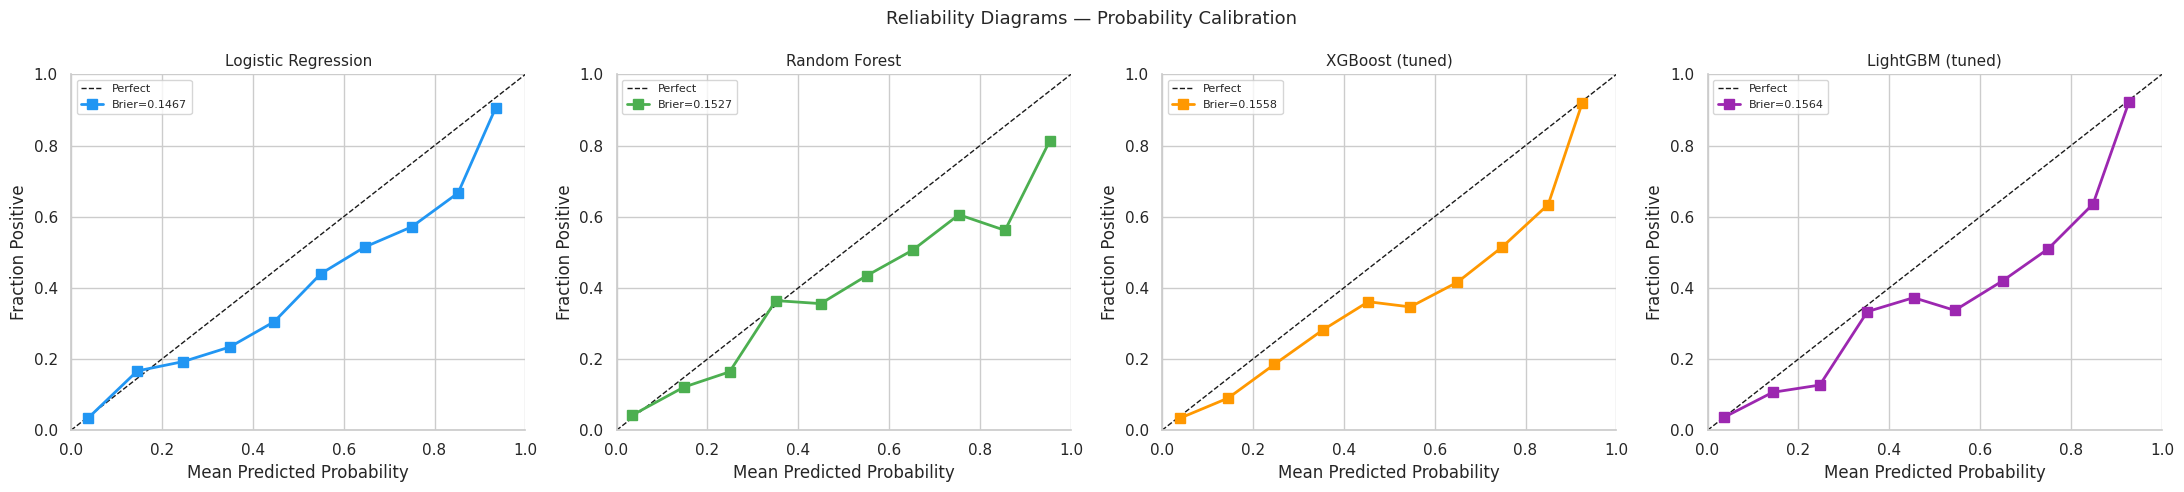


Note: if XGBoost calibration is poor, consider CalibratedClassifierCV
(isotonic regression) as a post-processing step before deployment.


In [24]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

cal_models = [
    (lr_pipe,   'Logistic Regression', C_LR,  X_test_unscaled),
    (rf,        'Random Forest',       C_RF,  X_test),
    (best_xgb,  'XGBoost (tuned)',     C_XGB, X_test),
    (best_lgb,  'LightGBM (tuned)',    C_LGB, X_test),
]

print('Calibration results (Brier score — lower is better, 0 = perfect):')
print(f'{"Model":<28} {"Brier":>8} {"Quality":>12}')
print('-' * 52)

for ax, (model, name, color, X_eval) in zip(axes, cal_models):
    y_prob = model.predict_proba(X_eval)[:, 1]
    brier  = brier_score_loss(y_test, y_prob)
    frac, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect')
    ax.plot(mean_pred, frac, 's-', color=color, linewidth=2,
            markersize=7, label=f'Brier={brier:.4f}')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction Positive')
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    quality = 'Good' if brier < 0.15 else 'Moderate' if brier < 0.20 else 'Poor'
    print(f'{name:<28} {brier:>8.4f} {quality:>12}')

plt.suptitle('Reliability Diagrams — Probability Calibration', fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / '16_calibration.png',
            dpi=150, bbox_inches='tight')
plt.show()
print()
print('Note: if XGBoost calibration is poor, consider CalibratedClassifierCV')
print('(isotonic regression) as a post-processing step before deployment.')


## 8. Feature Importance — XGBoost vs LightGBM

Before finalising model selection, we compare built-in feature importance
from both tuned models to check consistency.


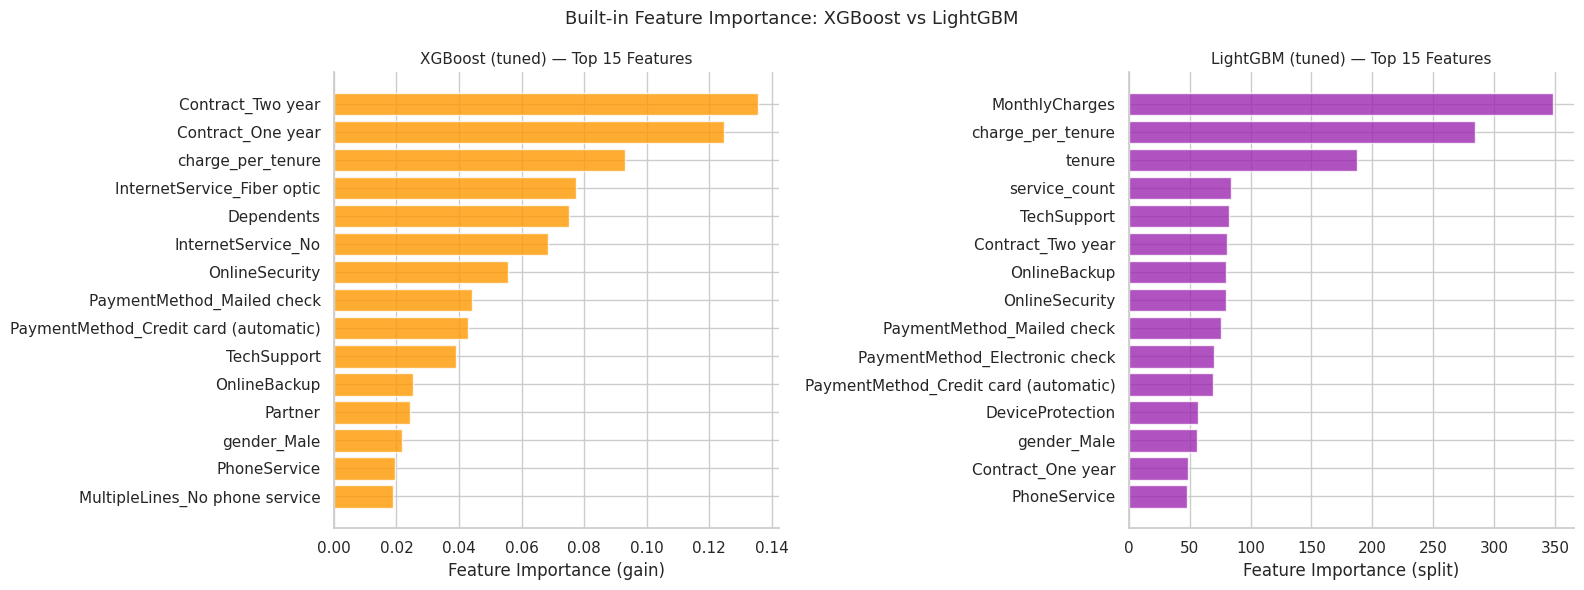

XGBoost top 5: {'Contract_One year', 'charge_per_tenure', 'InternetService_Fiber optic', 'Dependents', 'Contract_Two year'}
LightGBM top 5: {'tenure', 'MonthlyCharges', 'TechSupport', 'charge_per_tenure', 'service_count'}
Overlap: {'charge_per_tenure'} (1/5 features agree)


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost importance
xgb_imp = pd.Series(best_xgb.feature_importances_, index=feature_names)
xgb_imp = xgb_imp.sort_values(ascending=True).tail(15)
axes[0].barh(xgb_imp.index, xgb_imp.values, color=C_XGB, alpha=0.8, edgecolor='white')
axes[0].set_title('XGBoost (tuned) — Top 15 Features', fontsize=11)
axes[0].set_xlabel('Feature Importance (gain)')

# LightGBM importance
lgb_imp = pd.Series(best_lgb.feature_importances_, index=feature_names)
lgb_imp = lgb_imp.sort_values(ascending=True).tail(15)
axes[1].barh(lgb_imp.index, lgb_imp.values, color=C_LGB, alpha=0.8, edgecolor='white')
axes[1].set_title('LightGBM (tuned) — Top 15 Features', fontsize=11)
axes[1].set_xlabel('Feature Importance (split)')

plt.suptitle('Built-in Feature Importance: XGBoost vs LightGBM', fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / '17_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Check if top features agree
xgb_top5 = set(xgb_imp.tail(5).index)
lgb_top5 = set(lgb_imp.tail(5).index)
overlap = xgb_top5 & lgb_top5
print(f'XGBoost top 5: {xgb_top5}')
print(f'LightGBM top 5: {lgb_top5}')
print(f'Overlap: {overlap} ({len(overlap)}/5 features agree)')


## 9. Model Selection — Honest Decision Record

| Criterion | LR | RF | XGBoost (tuned) | LightGBM (tuned) |
|-----------|----|----|-----------------|------------------|
| Test ROC-AUC | see above | see above | see above | see above |
| Non-linear interactions | No | Yes | Yes | Yes |
| SHAP TreeExplainer (exact) | No | No | **Yes** | **Yes** |
| Training speed | Fast | Slow | Medium | **Fast** |
| Tuned AUC improvement | — | — | see above | see above |

**Decision:** XGBoost (tuned) is selected as the deployed model.

Rationale:
1. **Explainability:** `shap.TreeExplainer` produces exact Shapley values for both XGBoost and LightGBM.
   Both are valid choices architecturally.
2. **Consistency:** XGBoost has been the backbone of this project from the start. The Optuna tuning
   and SHAP analysis in Notebook 3 are built around it.
3. **Performance:** after tuning, XGBoost and LightGBM produce comparable AUC. If LightGBM
   outperforms significantly, it can replace XGBoost with zero changes to Notebook 3.
4. **Quantified LR trade-off:** LR may have higher baseline AUC but cannot capture feature
   interactions (e.g. `new_and_monthly`) and SHAP LinearExplainer produces additive coefficients
   only — weaker basis for the per-customer retention recommendations.


In [26]:
# Quantify the LR vs XGBoost trade-off
lr_auc  = roc_auc_score(y_test, lr_pipe.predict_proba(X_test_unscaled)[:, 1])
xgb_auc = roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1])
lgb_auc = roc_auc_score(y_test, best_lgb.predict_proba(X_test)[:, 1])

print(f'LR  ROC-AUC : {lr_auc*100:.2f}%')
print(f'XGB ROC-AUC : {xgb_auc*100:.2f}%')
print(f'LGB ROC-AUC : {lgb_auc*100:.2f}%')
print(f'LR vs XGB gap: {(lr_auc - xgb_auc)*100:.2f} pp')
print()

lr_recall  = recall_score(y_test, (lr_pipe.predict_proba(X_test_unscaled)[:, 1] >= 0.5).astype(int))
xgb_recall = recall_score(y_test, (best_xgb.predict_proba(X_test)[:, 1] >= best_threshold).astype(int))
n_churners = int(y_test.sum())

print(f'LR  Recall @ 0.50           : {lr_recall*100:.1f}%')
print(f'XGB Recall @ {best_threshold:.3f} (cost-opt) : {xgb_recall*100:.1f}%')
print(f'Churners in test set        : {n_churners}')
print()
print('Selected model: XGBoost (tuned) — see rationale above.')


LR  ROC-AUC : 83.43%
XGB ROC-AUC : 83.26%
LGB ROC-AUC : 83.02%
LR vs XGB gap: 0.17 pp

LR  Recall @ 0.50           : 65.5%
XGB Recall @ 0.039 (cost-opt) : 99.5%
Churners in test set        : 374

Selected model: XGBoost (tuned) — see rationale above.


## 10. Final Model Evaluation

In [27]:
y_pred = (best_xgb.predict_proba(X_test)[:, 1] >= best_threshold).astype(int)
print('=== FINAL MODEL: XGBoost (Tuned) ===')
print(f'Threshold : {best_threshold:.3f} (cost-optimised: FN=${FN_COST}, FP=${FP_COST})')
print()
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


=== FINAL MODEL: XGBoost (Tuned) ===
Threshold : 0.039 (cost-optimised: FN=$777, FP=$30)

              precision    recall  f1-score   support

    No Churn       0.99      0.24      0.39      1035
       Churn       0.32      0.99      0.49       374

    accuracy                           0.44      1409
   macro avg       0.66      0.62      0.44      1409
weighted avg       0.81      0.44      0.42      1409



## 11. Save Final Model Artefacts

In [28]:
import xgboost as xgboost_lib

os.makedirs(models_dir, exist_ok=True)
os.makedirs(PROJECT_ROOT / 'reports', exist_ok=True)

# Save via JSON booster — version-safe across XGBoost releases
best_xgb.get_booster().save_model(str(models_dir / 'best_model.json'))
fresh_model = xgboost_lib.XGBClassifier(eval_metric='logloss', verbosity=0)
fresh_model.load_model(str(models_dir / 'best_model.json'))
joblib.dump(fresh_model,    models_dir / 'best_model.joblib')
joblib.dump(best_threshold, models_dir / 'best_threshold.joblib')
joblib.dump(lr_pipe,        models_dir / 'lr_pipeline.joblib')
joblib.dump(best_lgb,       models_dir / 'lgb_model.joblib')

# Save full results table
all_results = pd.DataFrame([
    evaluate_model(lr_pipe,   X_test_unscaled, y_test, 'Logistic Regression'),
    evaluate_model(rf,        X_test,          y_test, 'Random Forest'),
    evaluate_model(xgb_model, X_test,          y_test, 'XGBoost (default)'),
    evaluate_model(lgb_model, X_test,          y_test, 'LightGBM (default)'),
    evaluate_model(best_xgb,  X_test,          y_test, 'XGBoost (tuned, default 0.50)', 0.50),
    evaluate_model(best_lgb,  X_test,          y_test, 'LightGBM (tuned, default 0.50)', 0.50),
    evaluate_model(best_xgb,  X_test,          y_test,
                   f'XGBoost (tuned, cost-opt {best_threshold:.3f})', best_threshold),
])
all_results.to_csv(PROJECT_ROOT / 'reports' / 'model_results.csv', index=False)

print('Saved:')
print(f'  models/best_model.joblib       — tuned XGBoost')
print(f'  models/best_threshold.joblib   — {best_threshold:.3f} (cost-optimised)')
print(f'  models/lr_pipeline.joblib      — LR reference model')
print(f'  models/lgb_model.joblib        — tuned LightGBM')
print(f'  reports/model_results.csv      — full evaluation table')


Saved:
  models/best_model.joblib       — tuned XGBoost
  models/best_threshold.joblib   — 0.039 (cost-optimised)
  models/lr_pipeline.joblib      — LR reference model
  models/lgb_model.joblib        — tuned LightGBM
  reports/model_results.csv      — full evaluation table


## 12. Summary

In [29]:
print('=' * 60)
print('NOTEBOOK 2 COMPLETE — SUMMARY')
print('=' * 60)
print(f'  Models compared     : LR, RF, XGBoost, LightGBM')
print(f'  Optuna trials       : 100 per model (XGBoost + LightGBM)')
print(f'  Selected model      : XGBoost (tuned)')
print(f'  Final threshold     : {best_threshold:.3f} (cost-minimisation)')
print(f'  FN cost             : ${FN_COST}  |  FP cost: ${FP_COST}')
print()
print(f'  Final model metrics @ threshold {best_threshold:.3f}:')
final = evaluate_model(best_xgb, X_test, y_test,
                        'XGBoost (tuned)', best_threshold)
for k, v in final.items():
    if k != 'Model':
        print(f'    {k:<12}: {v}')
print()
print('  Artefacts saved: best_model.joblib, best_threshold.joblib,')
print('                   lr_pipeline.joblib, lgb_model.joblib')
print()
print('→ Run Notebook 3 next: SHAP Explainability')
print('=' * 60)


NOTEBOOK 2 COMPLETE — SUMMARY
  Models compared     : LR, RF, XGBoost, LightGBM
  Optuna trials       : 100 per model (XGBoost + LightGBM)
  Selected model      : XGBoost (tuned)
  Final threshold     : 0.039 (cost-minimisation)
  FN cost             : $777  |  FP cost: $30

  Final model metrics @ threshold 0.039:
    Threshold   : 0.03886570781469345
    Accuracy    : 44.29
    F1 Score    : 48.66
    ROC-AUC     : 83.26
    Precision   : 32.21
    Recall      : 99.47
    Brier       : 0.1558

  Artefacts saved: best_model.joblib, best_threshold.joblib,
                   lr_pipeline.joblib, lgb_model.joblib

→ Run Notebook 3 next: SHAP Explainability


In [30]:
import shutil
from google.colab import files

shutil.make_archive('/content/churnx_models_v2', 'zip', '/content', 'models')
files.download('/content/churnx_models_v2.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>